# Edge-Overlap Baseline, Motif Fingerprint Stability, and Multi-Scale Feature Complementarity

This notebook demonstrates the analysis pipeline from the experiment on 200 Neuronpedia attribution graphs.

**What it does:**
- Computes **motif spectrum similarity** (cosine similarity of 4D motif count-ratio fingerprints)
- Computes **graph statistics similarity** (cosine similarity of 8D graph stat vectors)
- Runs **spectral clustering** at multiple K values and evaluates with NMI/ARI against ground-truth domain labels
- Tests **fingerprint stability** (within-domain vs between-domain similarity via Fisher Discriminant Ratio and Cohen's d)
- Assesses **complementarity** of motif vs edge-overlap vs graph-stats features
- Validates significance via **permutation tests**

The demo uses pre-computed feature vectors (motif count ratios, z-scores, graph statistics) extracted from pruned attribution graphs.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# igraph — NOT on Colab, always install
_pip('igraph==0.11.8')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import random
import time
from collections import Counter
from typing import Any

import numpy as np
import igraph
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats as scipy_stats
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter4_edge_overlap_ba/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['n_examples']} examples across {data['metadata']['n_domains']} domains")
print(f"Domains: {data['metadata']['domains']}")

Loaded 80 examples across 8 domains
Domains: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']


In [5]:
# ============================================================
# CONFIG — All tunable parameters (adjust for scale/speed)
# ============================================================
CLUSTER_K_VALUES = [2, 3, 4, 6, 8]  # Original: [2, 3, 4, 6, 8]
N_PERMUTATIONS = 200                 # Original: 500
SEED = 42

## Parse Feature Vectors

Extract pre-computed motif count-ratio fingerprints (4D), motif z-scores (4D), and graph statistics (8D) from each example. Build domain labels for clustering evaluation.

In [6]:
examples = data['examples']
n_total = len(examples)
domain_labels = [ex['domain'] for ex in examples]
domains_sorted = sorted(set(domain_labels))
domain_counts = dict(Counter(domain_labels))

le = LabelEncoder()
true_labels = le.fit_transform(domain_labels)

# Build feature matrices
motif_count_ratios = np.array([ex['motif_count_ratios'] for ex in examples])
motif_zscore_matrix = np.array([ex['motif_z_scores'] for ex in examples])
graph_stats_matrix = np.array([ex['graph_stats'] for ex in examples])

print(f"Feature matrices:")
print(f"  motif_count_ratios: {motif_count_ratios.shape}")
print(f"  motif_zscore_matrix: {motif_zscore_matrix.shape}")
print(f"  graph_stats_matrix: {graph_stats_matrix.shape}")
print(f"\nDomain distribution:")
for d, c in sorted(domain_counts.items()):
    print(f"  {d}: {c}")

Feature matrices:
  motif_count_ratios: (80, 4)
  motif_zscore_matrix: (80, 4)
  graph_stats_matrix: (80, 8)

Domain distribution:
  antonym: 10
  arithmetic: 10
  code_completion: 10
  country_capital: 10
  multi_hop_reasoning: 10
  rhyme: 10
  sentiment: 10
  translation: 10


## Helper Functions

Core analysis functions from the original pipeline: spectral clustering with dense eigensolver, clustering evaluation, permutation tests, fingerprint stability analysis, and similarity matrix statistics.

In [7]:
def _safe_spectral_cluster(
    affinity: np.ndarray, n_clusters: int, seed: int = 42, n_init: int = 5,
) -> np.ndarray:
    """Spectral clustering using dense LAPACK eigensolver (avoids ARPACK hangs)."""
    n = affinity.shape[0]
    degrees = affinity.sum(axis=1)
    degrees = np.maximum(degrees, 1e-10)
    d_inv_sqrt = 1.0 / np.sqrt(degrees)

    # Normalized Laplacian: I - D^{-1/2} A D^{-1/2}
    L_norm = np.eye(n) - (d_inv_sqrt[:, None] * affinity * d_inv_sqrt[None, :])

    eigenvalues, eigenvectors = np.linalg.eigh(L_norm)
    embedding = eigenvectors[:, :n_clusters].copy()

    norms = np.linalg.norm(embedding, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    embedding = embedding / norms

    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=n_init, max_iter=300)
    return km.fit_predict(embedding)


def cluster_with_affinity(
    affinity_matrix: np.ndarray, true_labels: np.ndarray,
    k_values: list, seed: int = 42,
) -> dict:
    """Spectral clustering on precomputed affinity at multiple K values."""
    n_samples = affinity_matrix.shape[0]
    results = {}

    affinity = np.clip(affinity_matrix, 0, None).copy()
    np.fill_diagonal(affinity, 1.0)

    for K in k_values:
        if K >= n_samples or K < 2:
            continue
        try:
            pred_labels = _safe_spectral_cluster(affinity, K, seed, n_init=10)
            nmi = normalized_mutual_info_score(true_labels, pred_labels)
            ari = adjusted_rand_score(true_labels, pred_labels)
            results[K] = {
                "nmi": float(nmi), "ari": float(ari),
                "pred_labels": pred_labels.tolist(),
            }
        except Exception as e:
            print(f"Clustering K={K} failed: {e}")
            results[K] = {"nmi": 0.0, "ari": 0.0, "pred_labels": []}
    return results


def permutation_test_nmi(
    affinity_matrix: np.ndarray, true_labels: np.ndarray,
    real_nmi: float, K: int, n_permutations: int, seed: int = 42,
) -> float:
    """Compute p-value via label permutation test."""
    affinity = np.clip(affinity_matrix, 0, None).copy()
    np.fill_diagonal(affinity, 1.0)
    n_samples = affinity.shape[0]
    if K >= n_samples or K < 2:
        return 1.0

    try:
        pred = _safe_spectral_cluster(affinity, K, seed, n_init=5)
    except Exception:
        return 1.0

    null_nmis = []
    for perm_i in range(n_permutations):
        shuffled = np.random.RandomState(seed + perm_i).permutation(true_labels)
        null_nmis.append(normalized_mutual_info_score(shuffled, pred))

    p_value = (np.sum(np.array(null_nmis) >= real_nmi) + 1) / (n_permutations + 1)
    return float(p_value)


def compute_stability(
    sim_matrix: np.ndarray, domain_labels: list,
) -> dict:
    """Compute within-domain vs between-domain similarity statistics."""
    domains = sorted(set(domain_labels))
    n = len(domain_labels)

    within_sims = []
    between_sims = []
    per_domain_within = {}

    domain_indices = {}
    for i, lab in enumerate(domain_labels):
        domain_indices.setdefault(lab, []).append(i)

    for d in domains:
        d_idx = domain_indices[d]
        d_within = []
        for a in range(len(d_idx)):
            for b in range(a + 1, len(d_idx)):
                val = sim_matrix[d_idx[a], d_idx[b]]
                within_sims.append(val)
                d_within.append(val)
        per_domain_within[d] = float(np.mean(d_within)) if d_within else 0.0

    for i in range(n):
        for j in range(i + 1, n):
            if domain_labels[i] != domain_labels[j]:
                between_sims.append(sim_matrix[i, j])

    within_arr = np.array(within_sims, dtype=float)
    between_arr = np.array(between_sims, dtype=float)

    mean_w = float(np.mean(within_arr)) if len(within_arr) > 0 else 0.0
    mean_b = float(np.mean(between_arr)) if len(between_arr) > 0 else 0.0
    var_w = float(np.var(within_arr)) if len(within_arr) > 0 else 0.0
    var_b = float(np.var(between_arr)) if len(between_arr) > 0 else 0.0

    denom = var_w + var_b
    fdr_discriminant = (mean_w - mean_b) ** 2 / denom if denom > 0 else 0.0
    pooled_std = math.sqrt((var_w + var_b) / 2)
    cohens_d = (mean_w - mean_b) / pooled_std if pooled_std > 0 else 0.0

    return {
        "mean_within": mean_w,
        "std_within": float(np.std(within_arr)) if len(within_arr) > 0 else 0.0,
        "mean_between": mean_b,
        "std_between": float(np.std(between_arr)) if len(between_arr) > 0 else 0.0,
        "fdr_discriminant": float(fdr_discriminant),
        "cohens_d": float(cohens_d),
        "per_domain_within": per_domain_within,
    }


def sim_matrix_stats(mat: np.ndarray, domain_labels: list) -> dict:
    """Compute distribution stats for a similarity matrix."""
    n = mat.shape[0]
    triu_idx = np.triu_indices(n, k=1)
    vals = mat[triu_idx]

    within_vals, between_vals = [], []
    for i in range(n):
        for j in range(i + 1, n):
            if domain_labels[i] == domain_labels[j]:
                within_vals.append(mat[i, j])
            else:
                between_vals.append(mat[i, j])

    return {
        "mean": float(np.mean(vals)), "median": float(np.median(vals)),
        "std": float(np.std(vals)),
        "within_domain_mean": float(np.mean(within_vals)) if within_vals else 0.0,
        "between_domain_mean": float(np.mean(between_vals)) if between_vals else 0.0,
    }


def map_clusters_to_domains(pred_labels: list, domain_labels: list) -> list:
    """Map cluster IDs to majority domain labels."""
    cluster_to_domain = {}
    for cluster_id in set(pred_labels):
        indices = [i for i, p in enumerate(pred_labels) if p == cluster_id]
        domains_in_cluster = [domain_labels[i] for i in indices]
        most_common = Counter(domains_in_cluster).most_common(1)[0][0]
        cluster_to_domain[cluster_id] = most_common
    return [cluster_to_domain[p] for p in pred_labels]

print("Helper functions defined.")

Helper functions defined.


## Phase C & D: Compute Similarity Matrices

Build pairwise similarity matrices from motif count-ratio fingerprints (cosine similarity) and graph statistics (cosine similarity of standardized features). These serve as affinity matrices for spectral clustering.

In [8]:
t_start = time.time()

# Phase C: Motif spectrum similarity (cosine similarity of 4D count-ratio vectors)
motif_cosine_sim = cosine_similarity(motif_count_ratios)
motif_euclidean_dist = cdist(motif_count_ratios, motif_count_ratios, "euclidean")
print(f"Motif cosine sim: mean={np.mean(motif_cosine_sim[np.triu_indices(n_total, k=1)]):.4f}")

# Phase D: Graph statistics similarity (cosine similarity of standardized 8D vectors)
scaler = StandardScaler()
graph_stats_scaled = scaler.fit_transform(graph_stats_matrix)
graph_stats_cosine_sim = cosine_similarity(graph_stats_scaled)
print(f"Graph stats cosine sim: mean={np.mean(graph_stats_cosine_sim[np.triu_indices(n_total, k=1)]):.4f}")

# Build affinity matrices (map cosine [-1,1] -> [0,1])
motif_affinity = (motif_cosine_sim + 1) / 2
graph_stats_affinity = (graph_stats_cosine_sim + 1) / 2

print(f"\nSimilarity matrices computed in {time.time() - t_start:.2f}s")

Motif cosine sim: mean=0.9986
Graph stats cosine sim: mean=0.0124

Similarity matrices computed in 0.00s


## Phase E: Clustering Comparison

Run spectral clustering on each similarity source (motif, graph stats, and combined features) at multiple K values. Evaluate with NMI and ARI against ground-truth domain labels, then run permutation tests for significance.

In [9]:
t_cluster = time.time()

# Define all similarity/affinity matrices to cluster
similarity_sources = {
    "motif_count_ratio": motif_affinity,
    "graph_stats": graph_stats_affinity,
    "motif_plus_graph_stats": (motif_affinity + graph_stats_affinity) / 2,
}

clustering_results = {}

for name, affinity_matrix in similarity_sources.items():
    t_c = time.time()
    res = cluster_with_affinity(affinity_matrix, true_labels, CLUSTER_K_VALUES, SEED)

    best_k = max(res, key=lambda k: res[k]["nmi"]) if res else 8
    best_nmi = res[best_k]["nmi"] if res else 0.0
    best_ari = res[best_k]["ari"] if res else 0.0

    clustering_results[name] = {
        "results_by_k": {
            str(k): {"nmi": v["nmi"], "ari": v["ari"]}
            for k, v in res.items()
        },
        "best_k": best_k,
        "best_nmi": best_nmi,
        "best_ari": best_ari,
        "pred_labels_best_k": res[best_k]["pred_labels"] if res and best_k in res else [],
    }

    print(f"  {name}: best_K={best_k}, NMI={best_nmi:.4f}, ARI={best_ari:.4f} ({time.time()-t_c:.1f}s)")

# Permutation tests
print(f"\nRunning permutation tests ({N_PERMUTATIONS} permutations)...")
for name, affinity_matrix in similarity_sources.items():
    best_k = clustering_results[name]["best_k"]
    real_nmi = clustering_results[name]["best_nmi"]
    p_val = permutation_test_nmi(affinity_matrix, true_labels, real_nmi, best_k, N_PERMUTATIONS, SEED)
    clustering_results[name]["perm_p_value"] = p_val
    print(f"  {name}: p-value={p_val:.4f}")

print(f"\nClustering complete in {time.time() - t_cluster:.2f}s")

  motif_count_ratio: best_K=6, NMI=0.5571, ARI=0.3618 (0.4s)


  graph_stats: best_K=8, NMI=0.8490, ARI=0.7191 (0.3s)
  motif_plus_graph_stats: best_K=8, NMI=0.8490, ARI=0.7191 (0.2s)

Running permutation tests (200 permutations)...


  motif_count_ratio: p-value=0.0050
  graph_stats: p-value=0.0050


  motif_plus_graph_stats: p-value=0.0050

Clustering complete in 1.33s


## Phase F: Fingerprint Stability Analysis

Measure how well each similarity metric separates within-domain pairs from between-domain pairs. Higher Fisher Discriminant Ratio (FDR) and Cohen's d indicate better domain-discriminating fingerprints.

In [10]:
stability_sources = {
    "motif_count_ratio": motif_affinity,
    "graph_stats": graph_stats_affinity,
    "motif_plus_graph_stats": (motif_affinity + graph_stats_affinity) / 2,
}

stability_results = {}
for name, sim_matrix in stability_sources.items():
    stab = compute_stability(sim_matrix, domain_labels)
    stability_results[name] = stab
    print(f"  {name}: within={stab['mean_within']:.4f}, between={stab['mean_between']:.4f}, "
          f"FDR={stab['fdr_discriminant']:.4f}, Cohen's d={stab['cohens_d']:.4f}")

  motif_count_ratio: within=0.9998, between=0.9992, FDR=0.3940, Cohen's d=0.8877
  graph_stats: within=0.9085, between=0.4545, FDR=2.0816, Cohen's d=2.0404
  motif_plus_graph_stats: within=0.9542, between=0.7268, FDR=2.0842, Cohen's d=2.0417


## Phase G: Complementarity Analysis

Compare clustering solutions from different feature types to assess whether they capture independent structural information. Low pairwise NMI between clustering solutions indicates complementary features.

In [11]:
# Get cluster labels from each core method at best K
best_K_comp = 8
comp_sources = {
    "motif": motif_affinity,
    "graph_stats": graph_stats_affinity,
}

cluster_labels_comp = {}
for name, aff in comp_sources.items():
    aff_clip = np.clip(aff, 0, None).copy()
    np.fill_diagonal(aff_clip, 1.0)
    try:
        if best_K_comp < n_total:
            labels = _safe_spectral_cluster(aff_clip, best_K_comp, SEED, n_init=10)
            cluster_labels_comp[name] = labels
    except Exception as e:
        print(f"  Complementarity clustering failed for {name}: {e}")

# Pairwise NMI between clustering solutions
complementarity_nmi = {}
comp_names = sorted(cluster_labels_comp.keys())
for a_name in comp_names:
    for b_name in comp_names:
        if a_name < b_name:
            nmi_ab = normalized_mutual_info_score(
                cluster_labels_comp[a_name], cluster_labels_comp[b_name],
            )
            key = f"{a_name}_vs_{b_name}"
            complementarity_nmi[key] = float(nmi_ab)
            print(f"  {key}: NMI={nmi_ab:.4f}")

# Check if combined beats individual
individual_methods = ["motif_count_ratio", "graph_stats"]
combined_methods = ["motif_plus_graph_stats"]

best_individual_nmi = max(
    (clustering_results[m]["best_nmi"] for m in individual_methods if m in clustering_results),
    default=0.0,
)
best_combined_nmi = max(
    (clustering_results[m]["best_nmi"] for m in combined_methods if m in clustering_results),
    default=0.0,
)
print(f"\n  Best individual NMI: {best_individual_nmi:.4f}")
print(f"  Best combined NMI: {best_combined_nmi:.4f}")
print(f"  Combined beats individual: {best_combined_nmi > best_individual_nmi}")

  graph_stats_vs_motif: NMI=0.4651

  Best individual NMI: 0.8490
  Best combined NMI: 0.8490
  Combined beats individual: False


## Results Visualization

Summary tables and plots showing clustering performance (NMI/ARI vs K), fingerprint stability metrics, and motif count-ratio distributions across domains.

CLUSTERING RESULTS (NMI / ARI by K)
Method                     K=2         K=3         K=4         K=6         K=8         Best_K  p-value
----------------------------------------------------------------------
motif_count_ratio          0.320     0.352     0.504     0.557     0.509     6       0.0050
graph_stats                0.471     0.615     0.618     0.765     0.849     8       0.0050
motif_plus_graph_stats     0.471     0.615     0.618     0.765     0.849     8       0.0050

FINGERPRINT STABILITY
Method                      Within  Between      FDR  Cohen d
----------------------------------------------------------------------
motif_count_ratio           0.9998   0.9992   0.3940   0.8877
graph_stats                 0.9085   0.4545   2.0816   2.0404
motif_plus_graph_stats      0.9542   0.7268   2.0842   2.0417


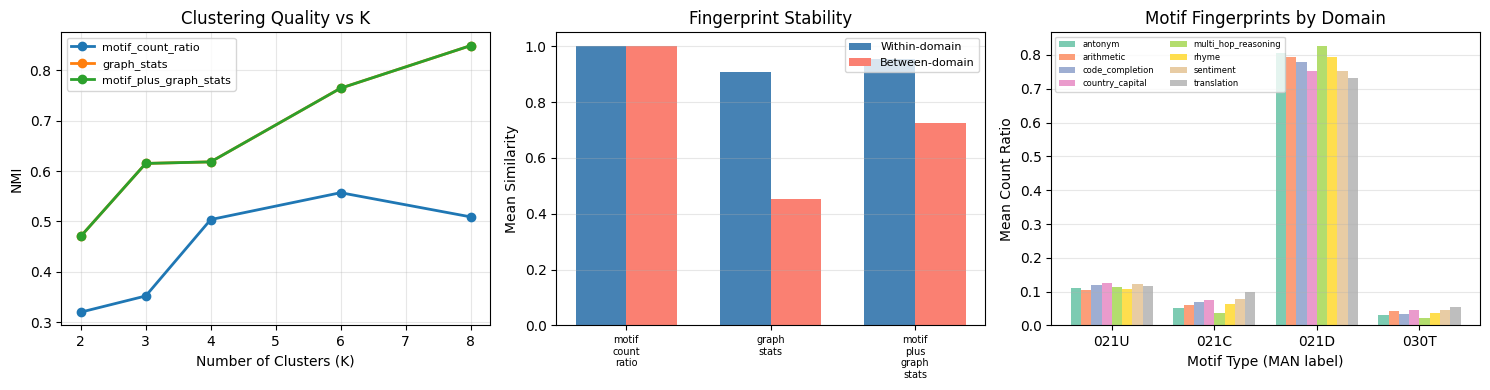


Visualization saved to results_visualization.png


In [12]:
# ============================================================
# Summary Table: Clustering Results
# ============================================================
print("=" * 70)
print("CLUSTERING RESULTS (NMI / ARI by K)")
print("=" * 70)
header = f"{'Method':<25}"
for k in CLUSTER_K_VALUES:
    header += f"  K={k:<8}"
header += "  Best_K  p-value"
print(header)
print("-" * 70)

for name, res in clustering_results.items():
    row = f"{name:<25}"
    for k in CLUSTER_K_VALUES:
        k_str = str(k)
        if k_str in res['results_by_k']:
            nmi = res['results_by_k'][k_str]['nmi']
            row += f"  {nmi:.3f}   "
        else:
            row += f"  {'N/A':<8}"
    row += f"  {res['best_k']:<7} {res.get('perm_p_value', -1):.4f}"
    print(row)

# ============================================================
# Summary Table: Fingerprint Stability
# ============================================================
print("\n" + "=" * 70)
print("FINGERPRINT STABILITY")
print("=" * 70)
print(f"{'Method':<25} {'Within':>8} {'Between':>8} {'FDR':>8} {'Cohen d':>8}")
print("-" * 70)
for name, stab in stability_results.items():
    print(f"{name:<25} {stab['mean_within']:>8.4f} {stab['mean_between']:>8.4f} "
          f"{stab['fdr_discriminant']:>8.4f} {stab['cohens_d']:>8.4f}")

# ============================================================
# Plot 1: NMI vs K for each method
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: NMI vs K
ax = axes[0]
for name, res in clustering_results.items():
    ks = sorted([int(k) for k in res['results_by_k'].keys()])
    nmis = [res['results_by_k'][str(k)]['nmi'] for k in ks]
    ax.plot(ks, nmis, 'o-', label=name, linewidth=2, markersize=6)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('NMI')
ax.set_title('Clustering Quality vs K')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Stability (within vs between)
ax = axes[1]
methods = list(stability_results.keys())
within_vals = [stability_results[m]['mean_within'] for m in methods]
between_vals = [stability_results[m]['mean_between'] for m in methods]
x = np.arange(len(methods))
width = 0.35
ax.bar(x - width/2, within_vals, width, label='Within-domain', color='steelblue')
ax.bar(x + width/2, between_vals, width, label='Between-domain', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', '\n') for m in methods], fontsize=7)
ax.set_ylabel('Mean Similarity')
ax.set_title('Fingerprint Stability')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Motif count-ratio distributions by domain
ax = axes[2]
motif_labels_map = data['metadata']['motif_labels']
motif_names = ['021U', '021C', '021D', '030T']
domain_means = {}
for d in domains_sorted:
    d_idx = [i for i, lab in enumerate(domain_labels) if lab == d]
    d_ratios = motif_count_ratios[d_idx].mean(axis=0)
    domain_means[d] = d_ratios

x = np.arange(len(motif_names))
n_domains = len(domains_sorted)
bar_width = 0.8 / n_domains
colors = plt.cm.Set2(np.linspace(0, 1, n_domains))

for di, d in enumerate(domains_sorted):
    ax.bar(x + di * bar_width - 0.4 + bar_width/2, domain_means[d],
           bar_width, label=d, color=colors[di], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(motif_names)
ax.set_xlabel('Motif Type (MAN label)')
ax.set_ylabel('Mean Count Ratio')
ax.set_title('Motif Fingerprints by Domain')
ax.legend(fontsize=6, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nVisualization saved to results_visualization.png")